<table>
  <tr>
    <td><div align="left"><font size="30">Block-diagram simulation</font></div></td>
    <td><img src="https://raw.githubusercontent.com/petercorke/bdsim/master/figs/BDSimLogo_NoBackgnd%402x.png" width="300"></td>
  </tr>
</table>

(c) Peter Corke 2026

In [ ]:
import importlib
import setup_tutorial
importlib.reload(setup_tutorial)
await setup_tutorial.setup_tutorial(required_toolboxes=['bdsim', 'roboticstoolbox'], required_packages=['matplotlib', 'numpy', 'scipy'])

import bdsim
import matplotlib.pyplot as plt
import numpy as np
import scipy

# A simple first-order system

![Block diagram sketch](https://raw.github.com/petercorke/bdsim/main/docs/figs/bd1-sketch.png)

In [1]:
import bdsim

sim = bdsim.BDSim(animation=True)  # create simulator
bd = sim.blockdiagram()  # create an empty block diagram

# define the blocks
demand = bd.STEP(T=1, name="demand")
sum = bd.SUM("+-")
gain = bd.GAIN(10)
plant = bd.LTI_SISO(0.5, [2, 1], name="plant")
scope = bd.SCOPE(styles=["k", "r--"], loc="lower right")

# connect the blocks
bd.connect(demand, sum[0], scope[1])
bd.connect(plant, sum[1])
bd.connect(sum, gain)
bd.connect(gain, plant)
bd.connect(plant, scope[0])

In [ ]:
bd.compile(verbose=True)  # check the diagram

bd.report_summary()

In [ ]:
out = sim.run(bd, T=5, watch=[demand, sum])  # simulate for 5s

In [ ]:
print(out)

# The classic "bouncing ball" system

In [ ]:
import bdsim

# define constants
g = -9.81  # gravity m/s2
e = 0.8  # coefficient of restitution
h0 = 10  # initial height m

sim = bdsim.BDSim(animation=True)  # create simulator
bd = sim.blockdiagram()  # create an empty block diagram

# define the blocks
gravity = bd.CONSTANT(g, name="gravity")

# chain of integrators
velocity = bd.INTEGRATOR(name="velocity", x0=0)  # initial height is initial velocity
position = bd.INTEGRATOR(name="position", x0=h0)

scope = bd.SCOPE(styles=["k", "r--"], loc="lower right")


# detect when the ball hits the ground (position=0) and trigger an event
def impact(event_block, state_map):
    state_map[velocity] *= -e  # reverse velocity and apply restitution


# connect the impact function to the event triggered when position crosses zero from above
ground = bd.EVENT("-", impact)

# connect the blocks together
bd.connect(gravity, velocity)
bd.connect(velocity, position)
bd.connect(velocity, scope[0])
bd.connect(position, scope[1])
bd.connect(position, ground)

bd.compile()  # check the diagram
bd.report_summary()


In [ ]:
out = sim.run(bd, T=5)  # , watch=[demand, sum])  # simulate for 5s

# Classical cart-pole system

In [ ]:
%run cartpole.py -q 

# A quadrotor controller

![quadrotor block diagram model](../../figs/fig4_24.png)

In [ ]:
%run quadrotor.py -q --tiles 2x2

# The block diagram editor

![complex](../../figs/computed-torque.svg)

`bdsim` includes a Qt-based editor called `bdedit`.  It provides a decent block diagram drawing environment and the results are saved in JSON files with a `.bd` extension.

These diagrams can be parsed into block diagram objects which can then be simulated, as in the examples above.

  INFORMATION: [Block.continuous('forward dynamics', type=fdyn, nin=1, nout=3, nstates=12, inames=['\tau'], onames=['q', 'qd', 'qdd'])] output 2 is not connected
  INFORMATION: [Block.source('Joint space trajectory', type=jtraj, nout=3, onames=['q', 'qd', 'qdd'])] output 2 is not connected


/var/folders/dh/fyyy32c92ksfpsjp1zrq_8780000gn/T/ipykernel_20524/2619631847.py:10: UserWarning: bdload is evaluating model expressions using eval(); load only trusted .bd files. Use allow_eval=False to disable expression evaluation.
  bd = bdload(bd, "computed-torque.bd", globalvars=globals())


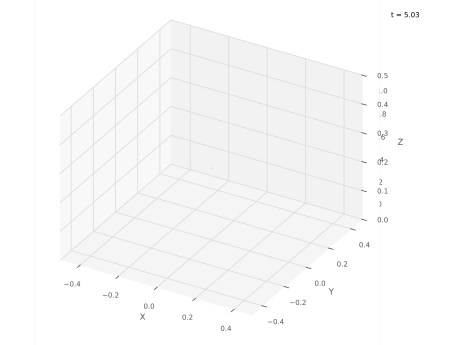

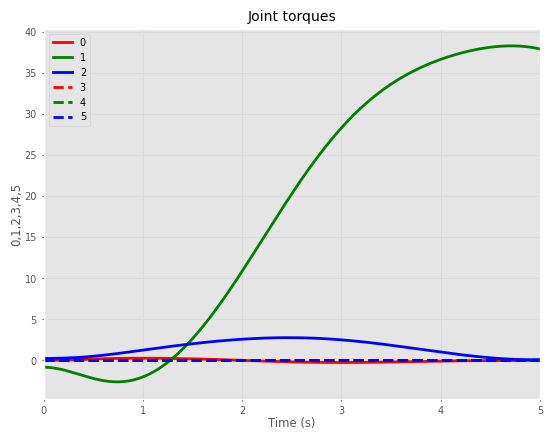

clock0::
         X      = ndarray:float64 (250, 6)
         Xnames = ['Tfb:X_0', 'Tfb:X_1', 'Tfb:X_2', 'Tfb:X_3', 'Tfb:X_4', 'Tfb:X_5'] (list)
         t      = ndarray:float64 (250,)
t      = ndarray:float64 (302,)
x      = ndarray:float64 (302, 12)
xnames = ['forward dynamics:x_0', 'forward dynamics:x_1', 'forward dynamics:x_2', 'forward dynamics:x_3', 'forward dynamics:x_4', 'forward dynamics:x_5', 'forward dynamics:x_6', 'forward dynamics:x_7', 'forward dynamics:x_8', 'forward dynamics:x_9', 'forward dynamics:x_10', 'forward dynamics:x_11'] (list)


In [2]:
from bdsim import BDSim, bdload
from roboticstoolbox.models.DH import Puma560

robot = Puma560().nofriction()

sim = BDSim(animation=True, quiet=True)
bd = sim.blockdiagram()
clock_fb = bd.clock(50, unit="Hz")

bd = bdload(bd, "computed-torque.bd", globalvars=globals())
bd.compile()

sim.report(bd, "summary")
out = sim.run(bd, 5)
print(out)


In [ ]:
out = sim.run(bd, T=5)